In [28]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import run_fair

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
nums = [1,2,3,4,5]
print(nums[1:], nums[:-1])

[2, 3, 4, 5] [1, 2, 3, 4]


In [113]:
# Run fair for train/test
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
dt = 1
freq_s = 1
nperseg = 250
fair_train = run_fair.initialise_fair(start, stop)
fair_test = run_fair.initialise_fair(start, stop)

#co2_train = np.linspace(0, 10, n_steps)
co2_train = np.random.randn(n_steps)
co2_test = np.linspace(0, 5, n_steps)
nan_force = np.linspace(0, 0, n_steps)

agents = ['CO2','CH4','N2O','Sulfur','BC']
emission_dict_train = {
  'CO2':co2_train,
  'CH4':nan_force,
  'N2O':nan_force,
  'Sulfur':nan_force,
  'BC':nan_force
}

emission_dict_test = {
  'CO2':co2_test,
  'CH4':nan_force,
  'N2O':nan_force,
  'Sulfur':nan_force,
  'BC':nan_force
}

t, T_ens, T_train, ECS = run_fair.run_multi_agent(fair_train, n_steps, years, agents, emission_dict_train)
t, T_ens, T_test, ECS = run_fair.run_multi_agent(fair_test, n_steps, years, agents, emission_dict_test)

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

In [114]:
agent = 'CO2'
conc_train = fair_train.concentration.sel(timebounds=slice(min(years), max(years))).loc[dict(scenario='custom')].sel(specie=agent).values
conc_train = np.mean(conc_train, axis=1)
conc_test = fair_test.concentration.sel(timebounds=slice(min(years), max(years))).loc[dict(scenario='custom')].sel(specie=agent).values
conc_test = np.mean(conc_test, axis=1)

In [115]:
extra_train = [conc_train]
extra_test = [conc_test]

In [116]:
def make_features(emissions, extras=None, n_lags=10):
  e = np.asarray(emissions, float).ravel()
  N = e.size
  X = np.zeros((N, n_lags + 1))
  for k in range(n_lags + 1):
    X[k:, k] = e[:N - k]  # zeros for out-of-bounds
  if extras:  # append any number of extra (unlagged) feature series
    cols = []
    for f in extras:
      f = np.asarray(f, float).ravel()
      v = np.zeros(N); v[:min(N, f.size)] = f[:N]  # truncate/pad with zeros
      cols.append(v)
    X = np.column_stack([X] + cols)
  return X

In [117]:
def train_mlp(emissions, gmst, extras=None, n_lags=10, random_state=0):
  X = make_features(emissions, extras, n_lags)
  y = np.asarray(gmst, float)[:X.shape[0]]
  model = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(64, 64), activation="relu",
                 max_iter=5000, early_stopping=True, random_state=random_state, shuffle=False)
  )
  model.fit(X, y)
  return model

In [118]:
def predict_series(model, emissions, extras=None, n_lags=10):
  return model.predict(make_features(emissions, extras, n_lags))

def rmse(y_true, y_pred):
  y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
  return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [128]:
model = train_mlp(co2_train, T_train, extra_train)
T_hat = predict_series(model, co2_test, extra_test)
print("RMSE:", rmse(T_test, T_hat))

RMSE: 0.14681038100233706


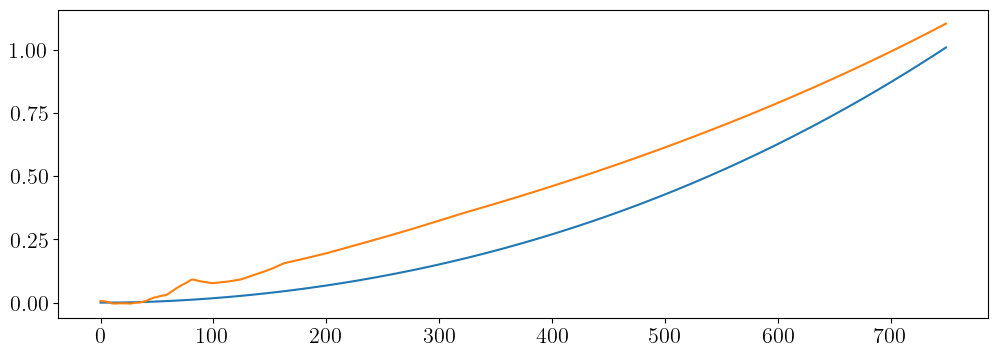

In [129]:
plt.plot(T_test)
#plt.plot(T_train)
plt.plot(T_hat)